In [1]:
print("OK")

OK


In [2]:
import pandas as pd
import numpy as np

import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [3]:
df=pd.read_csv("train.csv",usecols=['Age','Fare','Survived'])

In [4]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [5]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [6]:
df['Age'].fillna(df['Age'].mean(),inplace=True)

C:\Program Files\KMSpico\temp\ipykernel_21044\694922604.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace=True)


In [7]:
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [8]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [9]:
x=df.drop('Survived', axis=1)
y=df['Survived']

In [10]:
x.head()

,Age,Fare
0,22.0,7.2500
1,38.0,71.2833
2,26.0,7.9250
3,35.0,53.1000
4,35.0,8.0500


In [11]:
y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

In [12]:
y.dtype

dtype('int64')

In [13]:
type(y)

pandas.core.series.Series

In [14]:
x_train, x_test, y_train,y_test=train_test_split(x,y,test_size=20, random_state=42)

C:\Program Files\KMSpico\temp\ipykernel_21044\718055844.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train['Age'])


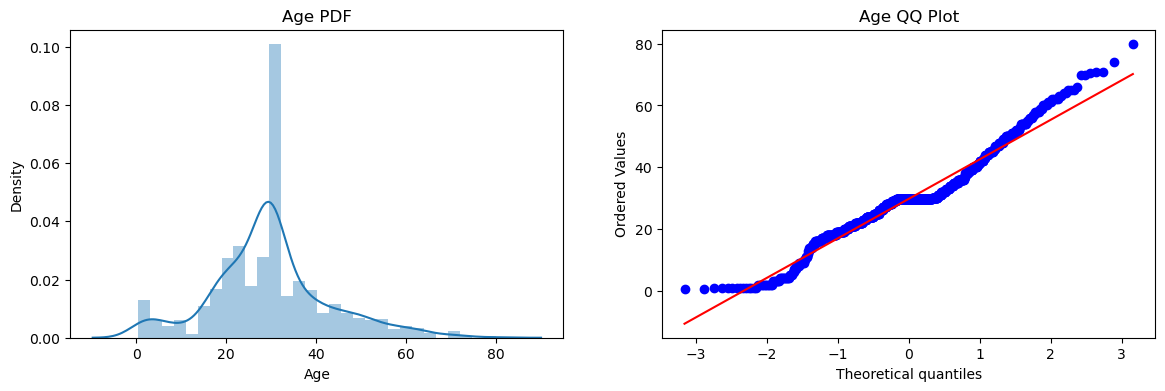

In [15]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(x_train['Age'])
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(x_train['Age'], dist="norm", plot=plt)
plt.title('Age QQ Plot')

plt.show()

C:\Program Files\KMSpico\temp\ipykernel_21044\3313795166.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train['Fare'])


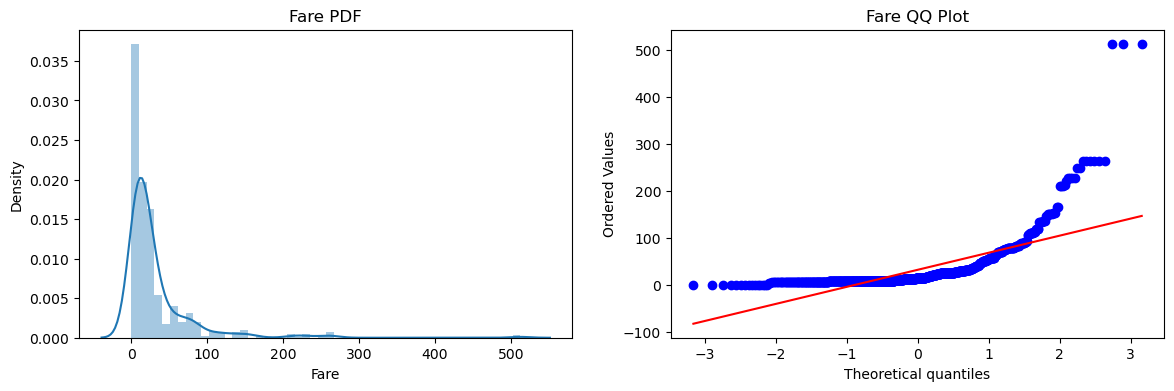

In [16]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(x_train['Fare'])
plt.title('Fare PDF')

plt.subplot(122)
stats.probplot(x_train['Fare'], dist="norm", plot=plt)
plt.title('Fare QQ Plot')

plt.show()

In [17]:
clf=LogisticRegression()
clf2=DecisionTreeClassifier()

In [18]:
clf.fit(x_train,y_train)
clf2.fit(x_train,y_train)


y_pred=clf.predict(x_test)
y_pred1=clf2.predict(x_test)

print("Accuracy LR", accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred1))

Accuracy LR 0.55
Accuracy DT 0.45


In [19]:
trf=FunctionTransformer(func=np.log1p)

In [20]:
x_train_transformed=trf.fit_transform(x_train)
x_test_transformed=trf.fit_transform(x_test)

In [21]:
x_train_transformed['Fare'].head()

294    2.185579
447    3.316003
192    2.180892
682    2.324836
538    2.740840
Name: Fare, dtype: float64

In [22]:
clf=LogisticRegression()
clf2=DecisionTreeClassifier()

clf.fit(x_train_transformed,y_train)
clf2.fit(x_train_transformed,y_train)

y_pred=clf.predict(x_test_transformed)
y_pred1=clf2.predict(x_test_transformed)

print("Accuracy LR", accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred1))



Accuracy LR 0.6
Accuracy DT 0.5


# Training Accuracy

In [23]:
# train accuracy 
y_train_pred = clf.predict(x_train_transformed)
y_train_pred1 = clf2.predict(x_train_transformed)
print("LR Train Accuracy:",
      accuracy_score(y_train, y_train_pred))

print("DT Train Accuracy:",
      accuracy_score(y_train, y_train_pred1))

LR Train Accuracy: 0.6819747416762342
DT Train Accuracy: 0.9529276693455798


# Using Cross_validation

In [24]:
x_transform=trf.fit_transform(x)
clf=LogisticRegression()
clf2=DecisionTreeClassifier()
print("LR", np.mean(cross_val_score(clf,x_transform,y,scoring='accuracy',cv=5)))
print("DT", np.mean(cross_val_score(clf2,x_transform,y,scoring='accuracy',cv=5)))

LR 0.6780114242671521
DT 0.6442219571903836


Text(0.5, 1.0, 'Fare After Log')

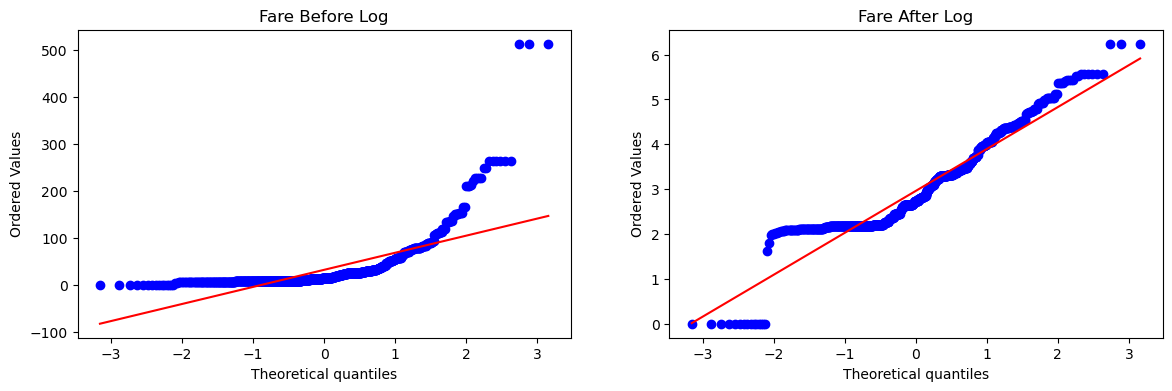

In [25]:
plt.figure(figsize=(14,4))
plt.subplot(121)
stats.probplot(x_train['Fare'],dist='norm',plot=plt)
plt.title('Fare Before Log')

plt.subplot(122)
stats.probplot(x_train_transformed['Fare'], dist='norm',plot=plt)
plt.title('Fare After Log')

Text(0.5, 1.0, 'Age After Log')

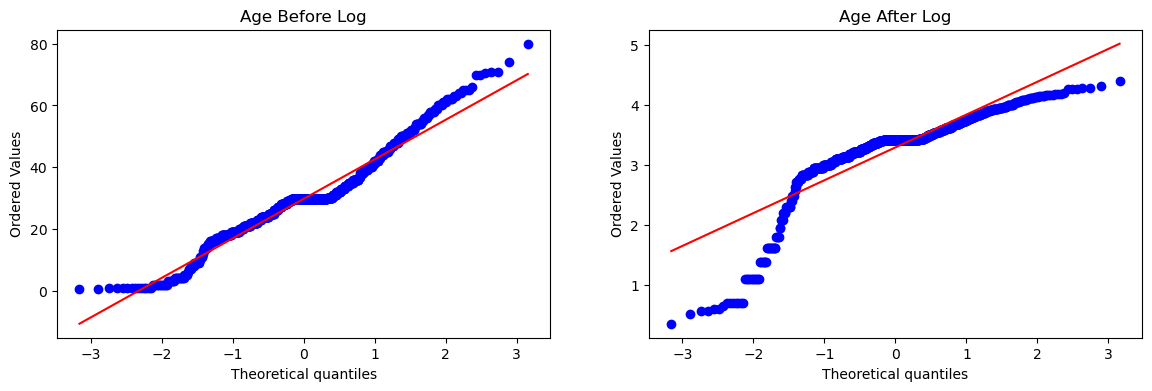

In [26]:
plt.figure(figsize=(14,4))
plt.subplot(121)
stats.probplot(x_train['Age'],dist='norm',plot=plt)
plt.title('Age Before Log')

plt.subplot(122)
stats.probplot(x_train_transformed['Age'], dist='norm',plot=plt)
plt.title('Age After Log')

# Column Transformer

In [27]:
trf2=ColumnTransformer(transformers=[
    ('log',FunctionTransformer(np.log1p),['Fare'])
    
    ],remainder='passthrough').set_output(transform='pandas')

x_train_transformed2=trf2.fit_transform(x_train)
x_test_transformed2=trf2.transform(x_test)

In [28]:
x_train_transformed2.head()

,log__Fare,remainder__Age
294,2.185579,24.000000
447,3.316003,34.000000
192,2.180892,19.000000
682,2.324836,20.000000
538,2.740840,29.699118


In [29]:
x_test_transformed2.head()

,log__Fare,remainder__Age
709,2.787834,29.699118
439,2.442347,31.000000
840,2.188856,20.000000
720,3.526361,6.000000
39,2.504848,14.000000


In [30]:
clf=LogisticRegression()
clf2=DecisionTreeClassifier()

clf.fit(x_train_transformed2,y_train)
clf2.fit(x_train_transformed2,y_train)

y_pred=clf.predict(x_test_transformed2)
y_pred2=clf2.predict(x_test_transformed2)

print("Accuracy LR", accuracy_score(y_test,y_pred))
print("Accuracy DT", accuracy_score(y_test, y_pred2))

Accuracy LR 0.65
Accuracy DT 0.5


In [31]:
x_transform=trf.fit_transform(x)
clf=LogisticRegression()
clf2=DecisionTreeClassifier()
print("LR", np.mean(cross_val_score(clf,x_transform,y,scoring='accuracy',cv=5)))
print("DT", np.mean(cross_val_score(clf2,x_transform,y,scoring='accuracy',cv=5)))

LR 0.6780114242671521
DT 0.6475990207771013


In [32]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [40]:
def apply_transform(transform):
    x=df.drop('Survived',axis=1)
    y=df['Survived']
    trf=ColumnTransformer(transformers=[
        ('log',FunctionTransformer(transform),['Fare'])
    ],remainder='passthrough').set_output(transform='pandas')
    x_train=trf.fit_transform(x)
    clf=LogisticRegression()

    print("Accuracy",np.mean(cross_val_score(clf,x_train,y,scoring='accuracy',cv=10)))

    print(x_train.columns)

    plt.figure(figsize=(14,4))
    plt.subplot(1,2,1)
    stats.probplot(x['Fare'],dist='norm',plot=plt)
    plt.title('Fare Before Transform')

    plt.subplot(1,2,2)
    stats.probplot(x_train['log__Fare'],dist='norm',plot=plt)
    plt.title('Fare After Transform')

    plt.show()


Accuracy 0.6712609238451936
Index(['log__Fare', 'remainder__Age'], dtype='object')


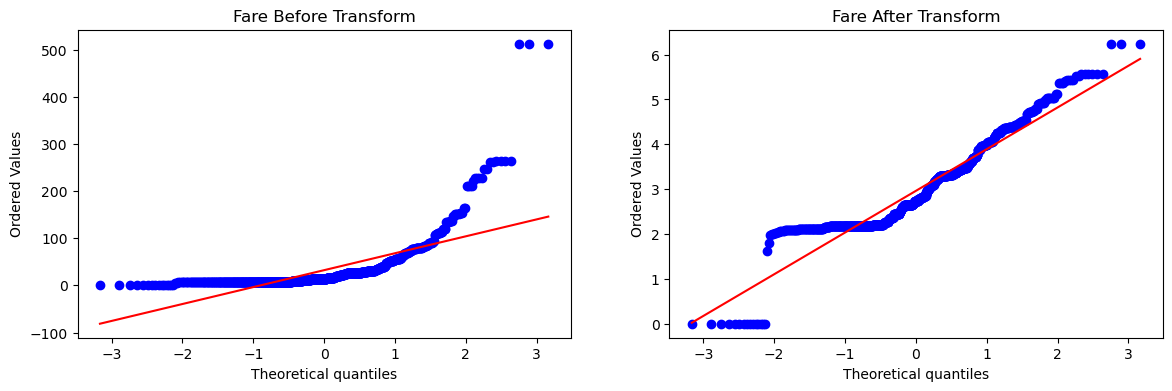

In [41]:
apply_transform(np.log1p)

Accuracy 0.6431335830212235
Index(['log__Fare', 'remainder__Age'], dtype='object')


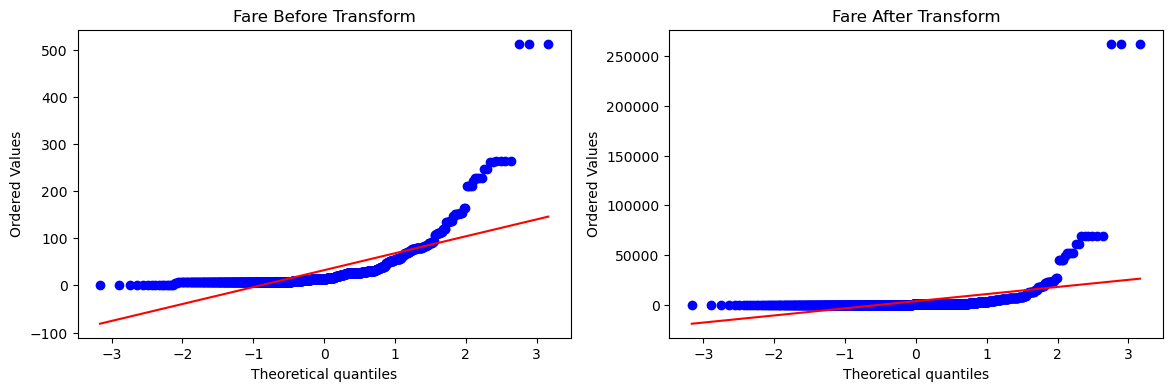

In [35]:

apply_transform(lambda x: x**2)


Accuracy 0.61729088639201
Index(['log__Fare', 'remainder__Age'], dtype='object')


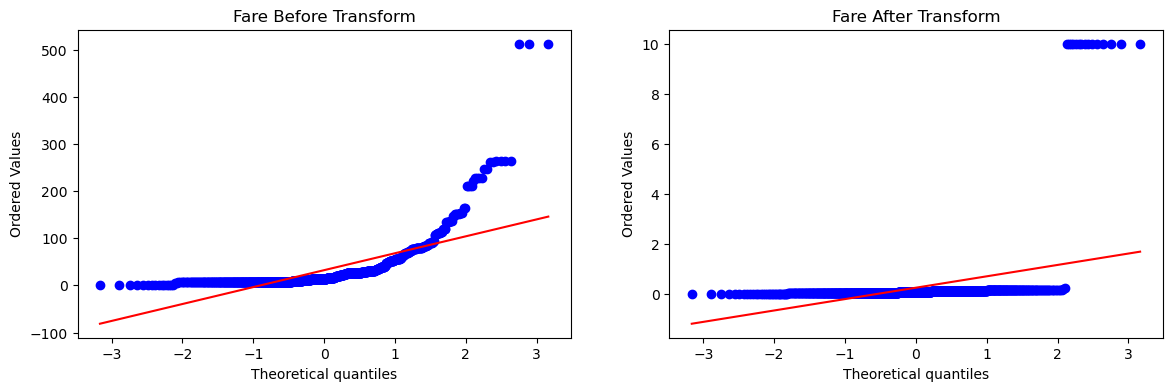

In [36]:
apply_transform(lambda x: 1/(x+0.1))

Accuracy 0.6589013732833957
Index(['log__Fare', 'remainder__Age'], dtype='object')


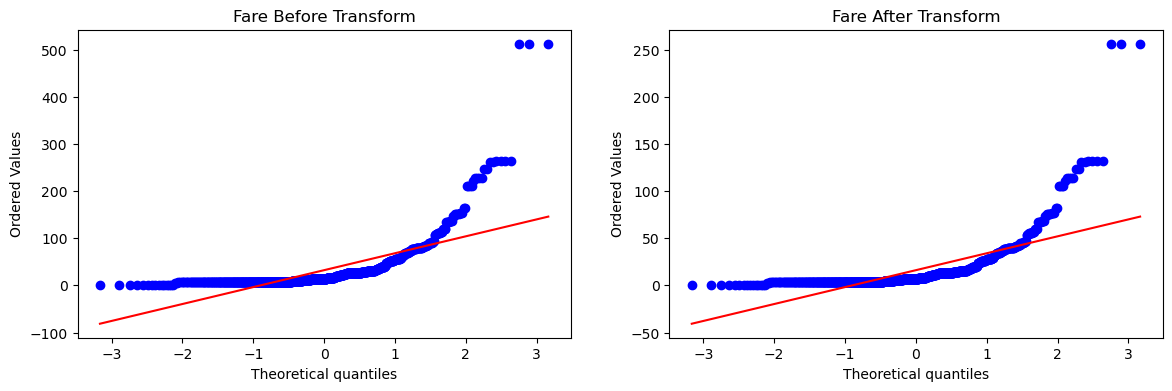

In [37]:
apply_transform(lambda x: x**1/2)